# Can Spotify Audio Features Explain Song Popularity?

## Project aim

This project investigates whether Spotify audio features can explain song popularity. The analysis uses a public archived Spotify tracks dataset containing track metadata, popularity scores, genres, artists and audio features. The main research question is:

**Can Spotify audio features explain song popularity?**

The project tests this by cleaning the dataset, defining popular songs as tracks at or above the 75th percentile of the popularity-score distribution, comparing audio features between popular and less-popular songs, examining genre-level popularity patterns, and testing whether a logistic regression model can predict popular-song status.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = Path("data/raw/spotify-tracks-dataset-detailed.csv")
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

# Consistent visual style for all exported figures
GREEN = "#1ED760"       
GREEN_DARK = "#1DB954"  
DARK = "#121212"
MUTED = "#535353"
GRID = "#d9e2dc"
PAPER = "#f7faf4"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "figure.facecolor": PAPER,
    "axes.facecolor": "white",
    "axes.edgecolor": DARK,
    "axes.labelcolor": DARK,
    "axes.titlecolor": DARK,
    "xtick.color": DARK,
    "ytick.color": DARK,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

## Data loading and inspection

In this section, I load the raw Spotify tracks dataset and check its structure before cleaning. I inspect the number of rows and columns, column names, data types and missing values so that the cleaning decisions are transparent and reproducible.

In [5]:
df = pd.read_csv(DATA_PATH, low_memory=False, skiprows=1)
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Initial data checks

Before cleaning the data, I first check the dataset size, column names, data types, missing values and summary statistics.

In [7]:
df.shape

(114000, 20)

In [8]:
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

In [10]:
df.isna().sum().sort_values(ascending=False)

album_name          1
track_name          1
artists             1
track_id            0
speechiness         0
time_signature      0
tempo               0
valence             0
liveness            0
instrumentalness    0
acousticness        0
loudness            0
mode                0
key                 0
energy              0
danceability        0
explicit            0
duration_ms         0
popularity          0
track_genre         0
dtype: int64

In [11]:
df.duplicated(subset="track_id").sum()

24259

In [12]:
audio_features = [
    "popularity", "duration_ms", "danceability", "energy", "loudness",
    "speechiness", "acousticness", "instrumentalness", "liveness",
    "valence", "tempo"
]

df[audio_features].describe()

,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,-8.258960,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837
std,22.305078,1.072977e+05,0.173542,0.251529,5.029337,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197
min,0.000000,0.000000e+00,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,-10.013000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750
50%,35.000000,2.129060e+05,0.580000,0.685000,-7.004000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000
75%,50.000000,2.615060e+05,0.695000,0.854000,-5.003000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000
max,100.000000,5.237295e+06,0.985000,1.000000,4.532000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000


The raw dataset contains 114,000 rows and 20 columns. Missing values are minimal, with only one missing value in each of the `artists`, `album_name` and `track_name` columns. The duplicate-track check shows that some track IDs appear more than once, so duplicate removal is needed before analysis. Overall, the main cleaning issues are incomplete track identifiers and repeated tracks rather than large-scale missing data.

## Data Cleaning

The cleaning process removes rows with missing core track information, drops duplicate tracks using `track_id`, and creates a readable duration variable in minutes. The original raw dataset is kept unchanged, while `df_clean` is used for the analysis.

This step is important because duplicate tracks or incomplete track identifiers could distort the popularity distribution, genre counts and model results. The output below summarises the final analysis dataset used for the rest of the project.

Spotify popularity is measured on a 0–100 scale. Rather than choosing a subjective label such as “hit” or “flop”, this project defines popular songs as tracks at or above the 75th percentile of the popularity-score distribution. This creates a transparent and reproducible threshold.

In [15]:
df_clean = df.copy()

# Remove rows with missing basic track information
df_clean = df_clean.dropna(subset=["track_id", "artists", "album_name", "track_name"])

# Remove duplicate tracks using track_id
df_clean = df_clean.drop_duplicates(subset="track_id")

# Create a duration variable in minutes for easier interpretation
df_clean["duration_min"] = df_clean["duration_ms"] / 60000

# Define popular songs as tracks at or above the 75th percentile of the popularity distribution
popularity_cutoff = df_clean["popularity"].quantile(0.75)
df_clean["popular_song"] = (df_clean["popularity"] >= popularity_cutoff).astype(int)

print("Raw dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)
print("Rows removed:", len(df) - len(df_clean))
print("Number of unique genres:", df_clean["track_genre"].nunique())
print("Number of unique artists:", df_clean["artists"].nunique())
print("Popularity cutoff:", popularity_cutoff)
print("Popular-song counts:")
print(df_clean["popular_song"].value_counts().sort_index())

Raw dataset shape: (114000, 20)
Cleaned dataset shape: (89740, 22)
Rows removed: 24260
Number of unique genres: 113
Number of unique artists: 31437
Popularity cutoff: 49.0
Popular-song counts:
popular_song
0    67220
1    22520
Name: count, dtype: int64


## Cleaning diagnostics and final analysis dataset

In [17]:
cleaning_summary = pd.DataFrame({
    "Step": [
        "Raw tracks",
        "Cleaned unique tracks",
        "Rows removed during cleaning",
        "Genres after cleaning",
        "Artists after cleaning",
        "Popularity cutoff",
        "Popular tracks",
        "Less popular tracks"
    ],
    "Value": [
        f"{len(df):,}",
        f"{len(df_clean):,}",
        f"{len(df) - len(df_clean):,}",
        f"{df_clean['track_genre'].nunique():,}",
        f"{df_clean['artists'].nunique():,}",
        f"{popularity_cutoff:.0f}",
        f"{df_clean['popular_song'].sum():,}",
        f"{(df_clean['popular_song'] == 0).sum():,}"
    ]
})

cleaning_summary

,Step,Value
0,Raw tracks,"114,000"
1,Cleaned unique tracks,"89,740"
2,Rows removed during cleaning,"24,260"
3,Genres after cleaning,113
4,Artists after cleaning,"31,437"
5,Popularity cutoff,49
6,Popular tracks,"22,520"
7,Less popular tracks,"67,220"


The raw dataset contained 114,000 tracks. After removing rows with missing core track information and dropping duplicate track IDs, the final analysis dataset contains 89,740 unique tracks. This cleaning step is important because duplicate observations could overweight some songs and distort the popularity distribution, genre counts and model results. The final dataset contains 113 genres and 31,437 artists, with 22,520 tracks classified as popular using the top-quartile popularity cutoff.

In [19]:
CLEAN_PATH = Path("data/cleaned/spotify_tracks_cleaned.csv")
CLEAN_PATH.parent.mkdir(parents=True, exist_ok=True)

df_clean.to_csv(CLEAN_PATH, index=False)

CLEAN_PATH

PosixPath('data/cleaned/spotify_tracks_cleaned.csv')

## Output 1: Dataset Summary

This summary table is used in the final blog post to present the cleaned analysis dataset, genre and artist coverage, and the popularity cutoff.

In [21]:
summary_table = pd.DataFrame({
    "Metric": [
        "Raw tracks",
        "Tracks after cleaning",
        "Number of genres",
        "Number of artists",
        "Popularity cutoff for popular songs",
        "Popular songs",
        "Less popular songs"
    ],
    "Value": [
        f"{len(df):,}",
        f"{len(df_clean):,}",
        f"{df_clean['track_genre'].nunique():,}",
        f"{df_clean['artists'].nunique():,}",
        f"{popularity_cutoff:.0f}",
        f"{df_clean['popular_song'].sum():,}",
        f"{(df_clean['popular_song'] == 0).sum():,}"
    ]
})

summary_table

,Metric,Value
0,Raw tracks,"114,000"
1,Tracks after cleaning,"89,740"
2,Number of genres,113
3,Number of artists,"31,437"
4,Popularity cutoff for popular songs,49
5,Popular songs,"22,520"
6,Less popular songs,"67,220"


## Class balance for the popularity model

Before modelling, I check the balance between popular and less-popular songs. This matters because if one class is much larger than the other, model accuracy can be misleading.

In [23]:
class_balance = (
    df_clean["popular_song"]
    .value_counts()
    .rename(index={0: "Less popular", 1: "Popular"})
    .reset_index()
)

class_balance.columns = ["Class", "Count"]
class_balance["Share"] = class_balance["Count"] / class_balance["Count"].sum()

class_balance

,Class,Count,Share
0,Less popular,67220,0.749053
1,Popular,22520,0.250947


The popular-song group contains 22,520 tracks, while the less-popular group contains 67,220 tracks. This means less-popular songs outnumber popular songs by about three to one. For this reason, model accuracy must be interpreted carefully, and recall and precision for the popular-song class are especially important.

## Output 2: Popularity Distribution

This chart shows how Spotify popularity scores are distributed across the cleaned dataset. The dashed line marks the popularity cutoff used to define popular songs.

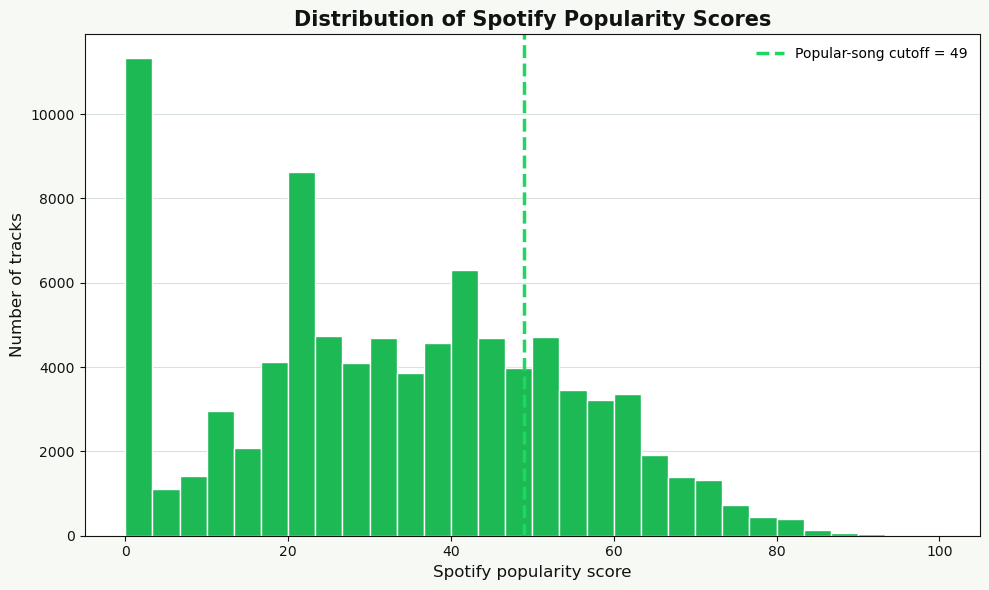

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    df_clean["popularity"],
    bins=30,
    color=GREEN_DARK,
    edgecolor="white"
)

ax.axvline(
    popularity_cutoff,
    color=GREEN,
    linestyle="--",
    linewidth=2.5,
    label=f"Popular-song cutoff = {int(popularity_cutoff)}"
)

ax.set_title("Distribution of Spotify Popularity Scores", fontweight="bold")
ax.set_xlabel("Spotify popularity score")
ax.set_ylabel("Number of tracks")
ax.set_axisbelow(True)
ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("figures/popularity_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Output 3: Popular vs Less Popular Songs

This table compares the average audio features of popular and less popular songs.

In [28]:
feature_compare = df_clean.groupby("popular_song")[[
    "danceability", "energy", "valence", "acousticness",
    "instrumentalness", "speechiness", "liveness", "duration_min"
]].mean().T

feature_compare.columns = ["Less popular", "Popular"]
feature_compare["Difference"] = feature_compare["Popular"] - feature_compare["Less popular"]

feature_compare.sort_values("Difference", ascending=False)

,Less popular,Popular,Difference
danceability,0.556446,0.579241,0.022796
speechiness,0.091011,0.076790,-0.014221
energy,0.638587,0.622136,-0.016451
acousticness,0.334661,0.309255,-0.025406
valence,0.476057,0.449826,-0.026231
liveness,0.226777,0.187701,-0.039076
instrumentalness,0.189077,0.126668,-0.062409
duration_min,3.866675,3.676984,-0.189691


## Output 4: Audio Feature Differences

This chart visualises which audio features are higher or lower on average among popular songs compared with less popular songs. Duration is excluded here because it is measured on a different scale from the 0–1 audio features.

In [30]:
feature_diff_no_duration = (
    feature_compare
    .drop(index="duration_min")
    ["Difference"]
    .sort_values()
)

feature_diff_no_duration

instrumentalness   -0.062409
liveness           -0.039076
valence            -0.026231
acousticness       -0.025406
energy             -0.016451
speechiness        -0.014221
danceability        0.022796
Name: Difference, dtype: float64

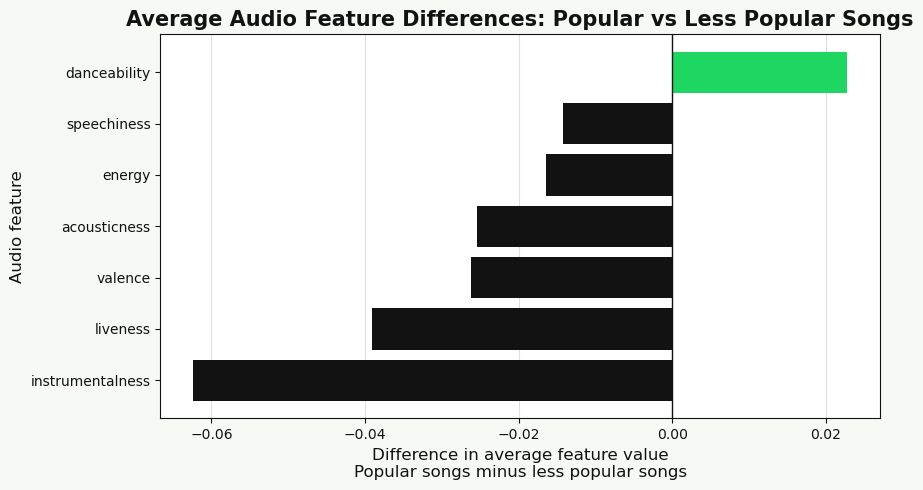

In [31]:
plt.figure(figsize=(9, 5))

plt.barh(
    feature_diff_no_duration.index,
    feature_diff_no_duration.values,
    color=[GREEN if value > 0 else DARK for value in feature_diff_no_duration.values],
    zorder=3
)

plt.axvline(0, color=DARK, linewidth=1, zorder=4)

plt.title(
    "Average Audio Feature Differences: Popular vs Less Popular Songs",
    fontweight="bold"
)
plt.xlabel("Difference in average feature value\nPopular songs minus less popular songs")
plt.ylabel("Audio feature")

plt.gca().set_axisbelow(True)
plt.grid(axis="x", color=GRID, linewidth=0.8, zorder=0)

plt.tight_layout()

plt.savefig(
    "figures/audio_feature_differences_no_duration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Output 5: Correlation Heatmap

This heatmap shows the correlations between Spotify popularity and the selected audio features.

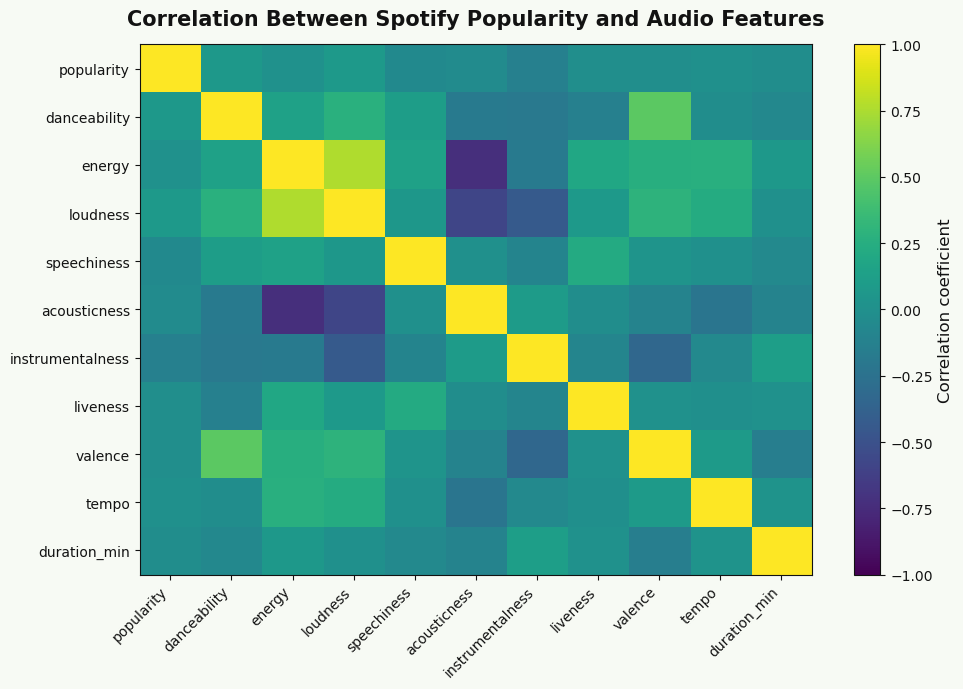

In [33]:
corr_features = [
    "popularity", "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence",
    "tempo", "duration_min"
]

corr_matrix = df_clean[corr_features].corr()

fig, ax = plt.subplots(figsize=(10, 7))

heatmap = ax.imshow(
    corr_matrix,
    cmap="viridis",
    vmin=-1,
    vmax=1,
    aspect="auto"
)

cbar = plt.colorbar(heatmap, ax=ax)
cbar.set_label("Correlation coefficient")

ax.set_xticks(range(len(corr_features)))
ax.set_yticks(range(len(corr_features)))
ax.set_xticklabels(corr_features, rotation=45, ha="right")
ax.set_yticklabels(corr_features)

ax.set_title(
    "Correlation Between Spotify Popularity and Audio Features",
    fontweight="bold",
    pad=14
)

plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

The heatmap shows that popularity is not strongly correlated with any single measured audio feature. Some audio features relate more clearly to each other, such as energy and loudness, but popularity does not appear to be explained by one obvious sonic dimension. This supports the wider finding that audio features alone cannot explain song popularity.

## Output 6: Modelling Popularity

The final stage tests whether Spotify audio features can classify songs as popular or less popular. The model uses audio features only, so the result directly tests whether measurable sonic characteristics are enough to identify popular tracks.

Because the dataset is imbalanced, accuracy alone is not enough to judge the model. The less-popular class is much larger than the popular-song class, so recall and precision for popular songs are more useful for interpreting whether the model actually identifies popular tracks.

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model_features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "duration_min", "explicit"
]

X = df_clean[model_features]
y = df_clean["popular_song"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logit_model = LogisticRegression(max_iter=1000)
logit_model.fit(X_train_scaled, y_train)

y_pred = logit_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7483396478716291

Classification report:
              precision    recall  f1-score   support

           0       0.75      0.99      0.86     16805
           1       0.45      0.01      0.03      5630

    accuracy                           0.75     22435
   macro avg       0.60      0.50      0.44     22435
weighted avg       0.68      0.75      0.65     22435


Confusion matrix:
[[16711    94]
 [ 5552    78]]


In [37]:
model_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Recall for less popular songs",
        "Recall for popular songs",
        "Precision for popular songs"
    ],
    "Value": [
        accuracy_score(y_test, y_pred),
        classification_report(y_test, y_pred, output_dict=True)["0"]["recall"],
        classification_report(y_test, y_pred, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred, output_dict=True)["1"]["precision"]
    ]
})

model_results

,Metric,Value
0,Accuracy,0.748340
1,Recall for less popular songs,0.994406
2,Recall for popular songs,0.013854
3,Precision for popular songs,0.453488


### Model interpretation

The logistic regression model achieves 0.748 accuracy, but this is misleading because the dataset is imbalanced. Less-popular songs outnumber popular songs by about three to one, so the model can achieve a high accuracy by mostly predicting the majority class.

The more important result is recall for popular songs. The model identifies only 0.0139 of popular tracks, meaning it correctly detects only about 1.4% of popular songs. Out of 5,630 popular songs in the test set, only 78 were correctly classified as popular. Precision for popular songs is 0.4535, so when the model predicts a song as popular, it is correct less than half of the time.

This suggests that Spotify audio features alone are weak predictors of popular-song status. The result supports the main argument of the project: measurable audio features describe some patterns, but they do not provide a reliable hit-song formula.

## Output 7: Popularity by Genre

Since audio features alone do not strongly distinguish popular songs, I also examine whether average popularity differs across genres. Genres with fewer than 300 tracks are excluded to avoid drawing conclusions from very small groups. Genre is not treated as a causal explanation, but it may capture wider listening contexts such as audience size, playlist visibility, fan communities and platform demand.

In [40]:
genre_popularity = (
    df_clean.groupby("track_genre")
    .agg(
        average_popularity=("popularity", "mean"),
        number_of_tracks=("track_id", "count")
    )
    .reset_index()
)

# Keeping genres with enough tracks to avoid tiny-sample weirdness
genre_popularity_filtered = genre_popularity[genre_popularity["number_of_tracks"] >= 300]

top_genres = genre_popularity_filtered.sort_values("average_popularity", ascending=False).head(15)

top_genres

,track_genre,average_popularity,number_of_tracks
65,k-pop,59.423581,916
81,pop-film,59.096933,815
15,chill,53.738683,972
68,latino,51.788945,398
94,sad,51.109929,564
44,grunge,50.587007,862
55,indian,49.765348,733
5,anime,48.776884,995
33,emo,48.500000,932
97,sertanejo,47.860775,826


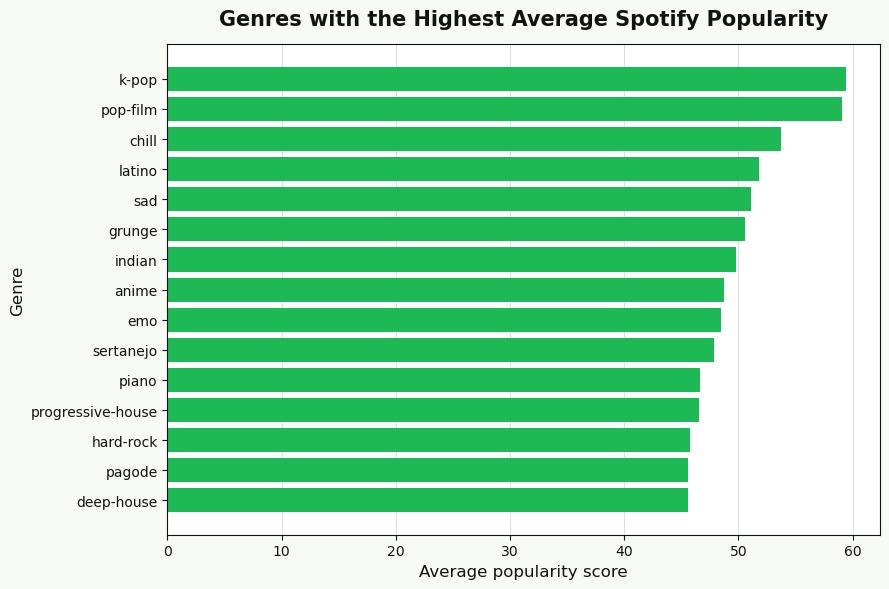

In [41]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    top_genres["track_genre"],
    top_genres["average_popularity"],
    color=GREEN_DARK
)

ax.invert_yaxis()

ax.set_title(
    "Genres with the Highest Average Spotify Popularity",
    fontweight="bold",
    pad=14
)
ax.set_xlabel("Average popularity score")
ax.set_ylabel("Genre")

ax.grid(axis="x", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("figures/top_genres_by_popularity.png", dpi=300, bbox_inches="tight")
plt.show()

The highest average-popularity genres include k-pop, pop-film, chill, latino and sad. This does not mean these genres cause popularity. Instead, genre may reflect wider audience and platform conditions that are not captured by audio features alone. This supports the wider conclusion that popularity is not explained by audio features only.

## Key Finding

Spotify audio features can explain some differences in song popularity, but they do not provide a simple “hit song formula”. Popular songs in this dataset are slightly more danceable and less instrumental, but the differences are modest rather than dramatic. The logistic regression model also performs poorly at identifying popular songs, suggesting that audio features alone are weak predictors of popularity.

The genre analysis strengthens this conclusion. Average popularity varies noticeably across genres, with k-pop, pop-film, chill and latino among the highest-scoring categories. This suggests that popularity may reflect wider listening contexts beyond audio features alone, such as genre communities, playlist exposure, artist visibility, marketing, social media attention and release timing, although these factors are not directly measured in this dataset.